# 03 — `train`

```
train.py
========
Training baseline YOLO26 small (object detection) untuk deteksi helm keselamatan.

Membaca parameter dari config.yaml, memvalidasi dataset & CUDA, lalu melatih
model dengan Ultralytics. Dilengkapi fallback otomatis saat CUDA Out Of Memory
(batch 8 -> 4 -> 2) dan penulisan ringkasan training.

Jalankan dari ROOT project (Windows):
    python src/train.py --config config.yaml
    python src/train.py --config config.yaml --model yolo26s.pt --epochs 50 --batch 8 --imgsz 640

Output:
    runs/train/<name>/              (bobot, plot, results.csv dari Ultralytics)
    runs/train/training_summary.txt (ringkasan + interpretasi metrik)

Catatan: READ-ONLY terhadap dataset (tidak menghapus / mengubah file asli).
```

Notebook ini adalah versi notebook dari [`src/train.py`](../src/train.py). Jalankan sel berurutan dari atas.

## Setup

In [1]:
# === Setup — jalankan sel ini lebih dulu ===
# Menemukan root project, menambahkan src/ ke sys.path, dan pindah (chdir) ke root
# agar semua path relatif (dataset/..., runs/...) berperilaku sama seperti
# menjalankan script dari root project.
import os, sys
from pathlib import Path

def find_project_root(start: Path) -> Path:
    for d in [start, *start.parents]:
        if (d / "src").is_dir() and (d / "dataset").exists():
            return d
    return start

PROJECT_ROOT = find_project_root(Path.cwd())
os.chdir(PROJECT_ROOT)
SRC = PROJECT_ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

print("PROJECT_ROOT:", PROJECT_ROOT)
print("cwd         :", Path.cwd())

PROJECT_ROOT: D:\ML\test-code\construction-safety-helmet-yolo26
cwd         : D:\ML\test-code\construction-safety-helmet-yolo26


## Apa yang dilakukan notebook ini
**Tujuan:** melatih model baseline **YOLO26s** untuk deteksi helm — tahap inti pipeline.

**Alur:** baca `config.yaml` → validasi dataset & CUDA → training dengan **fallback OOM otomatis batch 8→4→2** → ekstraksi metrik secara robust → tulis ringkasan + interpretasi.

**Parameter penting** (`config.yaml`): `imgsz=640`, `epochs=50`, `batch=8`, `patience=15` (early-stopping), `amp=True` (hemat VRAM).

**Output → `runs/train/helmet_yolo26s_baseline/`:** bobot `best.pt`/`last.pt`, `results.csv`, plot (kurva, confusion matrix, PR), dan `training_summary.txt`.

**Saat presentasi:** sel kode di bawah = isi lengkap [`src/train.py`](../src/train.py); cukup jalankan sel **Run**, lalu tunjuk visual hasil di bagian bawah notebook.

In [ ]:
from __future__ import annotations

import argparse
import csv
import gc
import logging
import sys
from datetime import datetime
from pathlib import Path

# Urutan fallback batch saat CUDA OOM (sesuai ketentuan: 8 -> 4 -> 2).
DEFAULT_FALLBACK_BATCHES = [8, 4, 2]

# Default keras (dipakai bila tidak ada di config maupun CLI).
HARD_DEFAULTS = {
    "data": "dataset/data.yaml",
    "model": "yolo26s.pt",
    "task": "detect",
    "imgsz": 640,
    "epochs": 50,
    "batch": 8,
    "device": 0,
    "workers": 4,
    "patience": 15,
    "seed": 42,
    "amp": True,
    "cache": False,
    "project": "runs/train",
    "name": "helmet_yolo26s_baseline",
}


def _line(char: str = "=", width: int = 64) -> str:
    return char * width


# --------------------------------------------------------------------------- #
# Konfigurasi
# --------------------------------------------------------------------------- #
def load_config(config_path: Path) -> dict:
    """Baca config.yaml (boleh tidak ada -> pakai default keras)."""
    if not config_path.is_file():
        print(f"[PERINGATAN] config '{config_path}' tidak ditemukan. Memakai default keras.")
        return {}
    try:
        import yaml
    except ImportError as exc:
        raise RuntimeError("PyYAML belum terinstal. Jalankan: pip install -r requirements.txt") from exc
    try:
        with config_path.open("r", encoding="utf-8") as fh:
            cfg = yaml.safe_load(fh) or {}
    except Exception as exc:
        raise RuntimeError(f"Gagal membaca config '{config_path}': {exc}") from exc
    if not isinstance(cfg, dict):
        raise RuntimeError("Isi config.yaml tidak valid (bukan mapping).")
    return cfg


def resolve_params(args: argparse.Namespace, cfg: dict) -> dict:
    """Gabungkan: CLI override > config.yaml > default keras.

    Key 'data' bisa berasal dari cfg['data_yaml'] atau cfg['data'].
    """
    def pick(cli_val, *cfg_keys, default=None):
        if cli_val is not None:
            return cli_val
        for k in cfg_keys:
            if k in cfg and cfg[k] is not None:
                return cfg[k]
        return default

    params = {
        "data": pick(args.data, "data_yaml", "data", default=HARD_DEFAULTS["data"]),
        "model": pick(args.model, "model", default=HARD_DEFAULTS["model"]),
        "task": pick(None, "task", default=HARD_DEFAULTS["task"]),
        "imgsz": int(pick(args.imgsz, "imgsz", default=HARD_DEFAULTS["imgsz"])),
        "epochs": int(pick(args.epochs, "epochs", default=HARD_DEFAULTS["epochs"])),
        "batch": int(pick(args.batch, "batch", default=HARD_DEFAULTS["batch"])),
        "device": pick(args.device, "device", default=HARD_DEFAULTS["device"]),
        "workers": int(pick(args.workers, "workers", default=HARD_DEFAULTS["workers"])),
        "patience": int(pick(args.patience, "patience", default=HARD_DEFAULTS["patience"])),
        "seed": int(pick(args.seed, "seed", default=HARD_DEFAULTS["seed"])),
        "amp": bool(pick(args.amp, "amp", default=HARD_DEFAULTS["amp"])),
        "cache": bool(pick(args.cache, "cache", default=HARD_DEFAULTS["cache"])),
        "project": pick(args.project, "project", default=HARD_DEFAULTS["project"]),
        "name": pick(args.name, "name", default=HARD_DEFAULTS["name"]),
    }
    return params


# --------------------------------------------------------------------------- #
# Pemeriksaan environment
# --------------------------------------------------------------------------- #
def check_cuda_and_gpu(device) -> tuple[bool, str]:
    """Cek CUDA & tampilkan GPU/VRAM. Return (ok_for_requested_device, gpu_name)."""
    try:
        import torch
    except ImportError as exc:
        raise RuntimeError("PyTorch belum terinstal. Instal PyTorch CUDA dari pytorch.org.") from exc

    want_cpu = str(device).lower() == "cpu"
    cuda_ok = torch.cuda.is_available()
    print(f"  PyTorch  : {torch.__version__}")
    print(f"  CUDA     : {'tersedia' if cuda_ok else 'TIDAK tersedia'} "
          f"(build {getattr(torch.version, 'cuda', None)})")

    gpu_name = "CPU"
    if cuda_ok:
        idx = 0
        if isinstance(device, int):
            idx = device
        elif isinstance(device, str) and device.isdigit():
            idx = int(device)
        try:
            props = torch.cuda.get_device_properties(idx)
            gpu_name = props.name
            print(f"  GPU [{idx}] : {props.name}")
            print(f"  VRAM     : {props.total_memory / 1024 ** 3:.2f} GB")
        except Exception as exc:
            print(f"  [PERINGATAN] gagal membaca properti GPU index {idx}: {exc}")

    if want_cpu:
        print("  Mode     : CPU (device='cpu') - training akan jauh lebih lambat.")
        return True, gpu_name
    return cuda_ok, gpu_name


def free_cuda() -> None:
    """Bersihkan cache CUDA antar percobaan training."""
    gc.collect()
    try:
        import torch
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
            torch.cuda.ipc_collect()
    except Exception:
        pass


def setup_file_logging(project: str, name: str) -> Path:
    """Pasang FileHandler ke logger Ultralytics agar output per-epoch tersimpan ke file.

    Log per-epoch (loss, P/R/mAP) dicatat lewat logger 'ultralytics' sehingga ikut
    tersimpan ke file ini — selamat dari restart/terminal tertutup (progress bar
    tqdm yang berbasis carriage-return tidak ikut, jadi file tetap rapi).
    """
    log_path = Path(project) / f"{name}_console.log"
    log_path.parent.mkdir(parents=True, exist_ok=True)
    ul_logger = logging.getLogger("ultralytics")
    target = str(log_path.resolve())
    for h in ul_logger.handlers:
        if isinstance(h, logging.FileHandler) and getattr(h, "baseFilename", "") == target:
            return log_path  # sudah terpasang, hindari duplikasi
    handler = logging.FileHandler(log_path, encoding="utf-8")
    handler.setFormatter(logging.Formatter("%(asctime)s | %(message)s", datefmt="%Y-%m-%d %H:%M:%S"))
    ul_logger.addHandler(handler)
    return log_path


def _is_oom_error(exc: Exception) -> bool:
    """Deteksi apakah exception merupakan CUDA Out Of Memory."""
    try:
        import torch
        oom_type = getattr(torch.cuda, "OutOfMemoryError", None)
        if oom_type is not None and isinstance(exc, oom_type):
            return True
    except Exception:
        pass
    msg = str(exc).lower()
    return "out of memory" in msg or "cuda oom" in msg


# --------------------------------------------------------------------------- #
# Training dengan fallback batch
# --------------------------------------------------------------------------- #
def build_batch_candidates(initial_batch: int) -> list[int]:
    """Bangun urutan batch: mulai dari initial, lalu 4, lalu 2 (unik, menurun)."""
    candidates: list[int] = []
    for b in [initial_batch, *DEFAULT_FALLBACK_BATCHES]:
        if b >= 1 and b not in candidates and (not candidates or b < candidates[-1]):
            candidates.append(b)
    # pastikan initial selalu dicoba pertama meski lebih kecil dari 8/4/2
    if candidates and candidates[0] != initial_batch:
        candidates = [initial_batch] + [b for b in candidates if b < initial_batch]
    return candidates


def train_with_fallback(params: dict, exist_ok: bool):
    """Latih model dengan fallback OOM. Return (model, results, batch_terpakai)."""
    from ultralytics import YOLO
    import torch

    candidates = build_batch_candidates(params["batch"])
    print(f"  Urutan batch yang akan dicoba (fallback OOM): {candidates}")

    # Ultralytics: project RELATIF di-resolve ke RUNS_DIR/task/project (mis. runs/detect/...).
    # Kirim path ABSOLUT agar output mendarat tepat di runs/train/<name> sesuai spesifikasi.
    abs_project = str(Path(params["project"]).resolve())

    last_exc: Exception | None = None
    for attempt, batch in enumerate(candidates, start=1):
        print()
        print(_line("-"))
        print(f"PERCOBAAN {attempt}/{len(candidates)} - batch={batch}")
        print(_line("-"))
        model = None
        try:
            model = YOLO(params["model"], task=params["task"])
            results = model.train(
                data=params["data"],
                epochs=params["epochs"],
                imgsz=params["imgsz"],
                batch=batch,
                device=params["device"],
                workers=params["workers"],
                patience=params["patience"],
                seed=params["seed"],
                amp=params["amp"],
                cache=params["cache"],
                project=abs_project,
                name=params["name"],
                exist_ok=exist_ok,
                verbose=True,
            )
            return model, results, batch
        except Exception as exc:  # noqa: BLE001 - kita klasifikasikan di bawah
            if _is_oom_error(exc):
                print(f"\n[OOM] CUDA kehabisan memori pada batch={batch}.")
                # Bersihkan model & cache sebelum mencoba batch lebih kecil.
                try:
                    del model
                except Exception:
                    pass
                free_cuda()
                last_exc = exc
                if attempt < len(candidates):
                    print(f"      -> membersihkan cache CUDA & mencoba batch {candidates[attempt]} ...")
                continue
            # Bukan OOM -> error lain, hentikan dengan pesan jelas.
            raise

    # Semua kandidat batch gagal karena OOM.
    raise RuntimeError(
        "Training GAGAL: CUDA Out Of Memory pada SEMUA batch yang dicoba "
        f"({candidates}). Saran: tutup aplikasi lain pemakai GPU, kurangi imgsz "
        "(mis. 512), set cache=False, atau gunakan device='cpu' (lambat). "
        f"Detail terakhir: {last_exc}"
    ) from last_exc


# --------------------------------------------------------------------------- #
# Ekstraksi metrik
# --------------------------------------------------------------------------- #
def extract_metrics(results, trainer) -> dict:
    """Ambil precision/recall/mAP50/mAP50-95 secara robust dari berbagai sumber."""
    p = r = m50 = m5095 = None

    # 1) Objek hasil train (DetMetrics) -> atribut .box
    box = getattr(results, "box", None)
    if box is not None:
        p = getattr(box, "mp", None)
        r = getattr(box, "mr", None)
        m50 = getattr(box, "map50", None)
        m5095 = getattr(box, "map", None)

    # 2) results.results_dict
    rd = getattr(results, "results_dict", None)
    if isinstance(rd, dict):
        p = p if p is not None else rd.get("metrics/precision(B)")
        r = r if r is not None else rd.get("metrics/recall(B)")
        m50 = m50 if m50 is not None else rd.get("metrics/mAP50(B)")
        m5095 = m5095 if m5095 is not None else rd.get("metrics/mAP50-95(B)")

    # 3) trainer.metrics
    tm = getattr(trainer, "metrics", None)
    if isinstance(tm, dict):
        p = p if p is not None else tm.get("metrics/precision(B)")
        r = r if r is not None else tm.get("metrics/recall(B)")
        m50 = m50 if m50 is not None else tm.get("metrics/mAP50(B)")
        m5095 = m5095 if m5095 is not None else tm.get("metrics/mAP50-95(B)")

    # 4) Fallback: parse results.csv (ambil baris dengan mAP50-95 terbaik)
    if None in (p, r, m50, m5095):
        save_dir = getattr(trainer, "save_dir", None)
        if save_dir is not None:
            csv_p, csv_r, csv_m50, csv_m5095 = _metrics_from_csv(Path(save_dir) / "results.csv")
            p = p if p is not None else csv_p
            r = r if r is not None else csv_r
            m50 = m50 if m50 is not None else csv_m50
            m5095 = m5095 if m5095 is not None else csv_m5095

    def _f(v):
        try:
            return float(v)
        except (TypeError, ValueError):
            return None

    return {"precision": _f(p), "recall": _f(r), "map50": _f(m50), "map5095": _f(m5095)}


def _metrics_from_csv(csv_path: Path):
    """Ambil metrik dari baris hasil terbaik (mAP50-95 tertinggi) di results.csv."""
    if not csv_path.is_file():
        return None, None, None, None
    try:
        with csv_path.open("r", encoding="utf-8") as fh:
            rows = list(csv.DictReader(fh))
    except Exception:
        return None, None, None, None
    if not rows:
        return None, None, None, None

    def col(row, key):
        for k in row:
            if k.strip() == key:
                try:
                    return float(row[k])
                except (TypeError, ValueError):
                    return None
        return None

    best = max(rows, key=lambda rw: (col(rw, "metrics/mAP50-95(B)") or -1.0))
    return (col(best, "metrics/precision(B)"), col(best, "metrics/recall(B)"),
            col(best, "metrics/mAP50(B)"), col(best, "metrics/mAP50-95(B)"))


# --------------------------------------------------------------------------- #
# Ringkasan training
# --------------------------------------------------------------------------- #
def _fmt(v) -> str:
    return f"{v:.4f}" if isinstance(v, (int, float)) else "N/A"


def build_summary(params: dict, batch_used: int, save_dir: Path,
                  best: Path, last: Path, metrics: dict, gpu_name: str) -> str:
    p = metrics.get("precision")
    r = metrics.get("recall")
    m50 = metrics.get("map50")
    m5095 = metrics.get("map5095")

    L: list[str] = []
    L.append(_line())
    L.append("RINGKASAN TRAINING - YOLO26s (object detection)")
    L.append(_line())
    L.append(f"Waktu            : {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
    L.append(f"1. Dataset       : {params['data']}")
    L.append(f"2. Model         : {params['model']}")
    L.append(f"3. Image size    : {params['imgsz']}")
    L.append(f"4. Epoch         : {params['epochs']} (patience={params['patience']})")
    L.append(f"5. Batch final   : {batch_used}"
             + ("" if batch_used == params["batch"] else f"  (turun dari {params['batch']} karena OOM)"))
    L.append(f"6. Device        : {params['device']} ({gpu_name})")
    L.append(f"   Save dir      : {save_dir}")
    L.append(f"7. best.pt       : {best}")
    L.append(f"8. last.pt       : {last}")
    L.append("")
    L.append("METRIK VALIDASI (bobot terbaik)")
    L.append("-" * 64)
    L.append(f"9.  Precision    : {_fmt(p)}")
    L.append(f"10. Recall       : {_fmt(r)}")
    L.append(f"11. mAP50        : {_fmt(m50)}")
    L.append(f"12. mAP50-95     : {_fmt(m5095)}")
    L.append("")
    L.append("CATATAN INTERPRETASI METRIK")
    L.append("-" * 64)
    L.append("1. Precision tinggi tetapi recall rendah  -> model cenderung konservatif")
    L.append("   (banyak objek terlewat / kurang berani mendeteksi).")
    L.append("2. Recall tinggi tetapi precision rendah  -> banyak false positive")
    L.append("   (model terlalu sering mendeteksi, banyak deteksi salah).")
    L.append("3. mAP50 tinggi tetapi mAP50-95 rendah    -> objek sudah dikenali,")
    L.append("   namun lokalisasi bounding box belum presisi (IoU ketat masih lemah).")
    L.append("")
    L.append("ANALISIS OTOMATIS")
    L.append("-" * 64)
    notes = analyze_metrics(p, r, m50, m5095)
    for n in notes:
        L.append(f"- {n}")
    L.append("")
    L.append(_line())
    return "\n".join(L)


def analyze_metrics(p, r, m50, m5095) -> list[str]:
    """Terapkan 3 catatan interpretasi sesuai nilai metrik aktual."""
    notes: list[str] = []
    if None in (p, r):
        notes.append("Precision/Recall tidak terbaca otomatis; cek results.csv di save dir.")
    else:
        gap = p - r
        if gap >= 0.15:
            notes.append(f"Precision ({p:.3f}) jauh di atas Recall ({r:.3f}): model KONSERVATIF, "
                         "banyak objek kemungkinan terlewat. Pertimbangkan turunkan conf threshold / tambah data.")
        elif gap <= -0.15:
            notes.append(f"Recall ({r:.3f}) jauh di atas Precision ({p:.3f}): banyak FALSE POSITIVE. "
                         "Pertimbangkan naikkan conf threshold / perbaiki kualitas anotasi.")
        else:
            notes.append(f"Precision ({p:.3f}) dan Recall ({r:.3f}) cukup seimbang.")

    if None in (m50, m5095):
        notes.append("mAP tidak terbaca otomatis; cek results.csv di save dir.")
    else:
        if m50 >= 0.5 and (m50 - m5095) >= 0.20:
            notes.append(f"mAP50 ({m50:.3f}) jauh di atas mAP50-95 ({m5095:.3f}): objek DIKENALI namun "
                         "LOKALISASI bbox kurang presisi. Pertimbangkan latih lebih lama / augmentasi geometris.")
        else:
            notes.append(f"Selisih mAP50 ({m50:.3f}) vs mAP50-95 ({m5095:.3f}) wajar; lokalisasi relatif baik.")
    return notes


# --------------------------------------------------------------------------- #
# Main
# --------------------------------------------------------------------------- #
def parse_args(argv: list[str] | None = None) -> argparse.Namespace:
    p = argparse.ArgumentParser(description="Training baseline YOLO26s (object detection).")
    p.add_argument("--config", default="config.yaml", help="Path config.yaml (default: config.yaml).")
    # Override (None = pakai config/default)
    p.add_argument("--data", default=None, help="Override path data.yaml.")
    p.add_argument("--model", default=None, help="Override model (default: yolo26s.pt).")
    p.add_argument("--imgsz", type=int, default=None, help="Override image size.")
    p.add_argument("--epochs", type=int, default=None, help="Override jumlah epoch.")
    p.add_argument("--batch", type=int, default=None, help="Override batch awal (fallback ke 4, 2 bila OOM).")
    p.add_argument("--device", default=None, help="Override device (0 untuk GPU, 'cpu' untuk CPU).")
    p.add_argument("--workers", type=int, default=None, help="Override jumlah workers dataloader.")
    p.add_argument("--patience", type=int, default=None, help="Override early-stopping patience.")
    p.add_argument("--seed", type=int, default=None, help="Override random seed.")
    p.add_argument("--name", default=None, help="Override nama run (folder di runs/train).")
    p.add_argument("--project", default=None, help="Override folder project output.")
    p.add_argument("--amp", action=argparse.BooleanOptionalAction, default=None,
                   help="Aktifkan/nonaktifkan AMP (--amp / --no-amp).")
    p.add_argument("--cache", action=argparse.BooleanOptionalAction, default=None,
                   help="Aktifkan/nonaktifkan cache (--cache / --no-cache).")
    p.add_argument("--exist-ok", dest="exist_ok", action=argparse.BooleanOptionalAction, default=True,
                   help="Tulis ke folder run yang sama bila sudah ada (default: aktif).")
    return p.parse_args(argv)


def main(argv: list[str] | None = None) -> int:
    args = parse_args(argv)

    print(_line())
    print("TRAINING YOLO26s - Construction Safety Helmet")
    print(_line())

    # 1) Config + parameter
    try:
        cfg = load_config(Path(args.config))
        params = resolve_params(args, cfg)
    except RuntimeError as exc:
        print(f"[ERROR] {exc}")
        return 2

    print("Parameter efektif:")
    for k in ("data", "model", "task", "imgsz", "epochs", "batch", "device",
              "workers", "patience", "seed", "amp", "cache", "project", "name"):
        print(f"  {k:<9}: {params[k]}")
    print()

    # 2) Validasi dataset
    data_path = Path(params["data"])
    if not data_path.is_file():
        print(f"[ERROR] data.yaml tidak ditemukan: {data_path}")
        print("        Pastikan path benar (mis. dataset/data.yaml) & jalankan dari root project.")
        return 2

    # 3-4) Cek CUDA & GPU
    print("Pemeriksaan environment:")
    try:
        device_ok, gpu_name = check_cuda_and_gpu(params["device"])
    except RuntimeError as exc:
        print(f"[ERROR] {exc}")
        return 2
    if not device_ok:
        print()
        print("[ERROR] CUDA tidak tersedia padahal device GPU diminta "
              f"(device={params['device']}).")
        print("        Periksa instalasi PyTorch CUDA / driver NVIDIA (nvidia-smi),")
        print("        atau jalankan ulang dengan: --device cpu (jauh lebih lambat).")
        return 2

    # Auto-logging ke file (selamat dari restart/terminal tertutup).
    log_path = setup_file_logging(params["project"], params["name"])
    print(f"Log konsol disimpan ke: {log_path}")
    print()

    # TODO (bergantung isi dataset): EDA menunjukkan kelas 'No-Helmet' adalah minoritas
    # (~8% dari total bbox; rasio imbalance ~6x terhadap kelas mayoritas). Hal ini bisa
    # menekan recall 'No-Helmet'. Cara cek setelah training:
    #   - lihat recall per-kelas di runs/evaluate/val_metrics.csv (jalankan src/evaluate.py)
    #   - jalankan ulang src/eda.py lalu cek runs/eda/class_distribution.csv
    # Jika recall 'No-Helmet' rendah: tambah data kelas tsb / augmentasi terarah.
    # (Catatan: dataset memuat sedikit label segmentasi nyasar yang otomatis dibuang
    #  Ultralytics saat training; verifikasi via src/validate_dataset.py -> bad_labels.csv.)

    # 5-8) Training + fallback OOM
    try:
        model, results, batch_used = train_with_fallback(params, exist_ok=args.exist_ok)
    except RuntimeError as exc:
        print(f"\n[ERROR] {exc}")
        return 1
    except KeyboardInterrupt:
        print("\n[INFO] Training dibatalkan oleh pengguna.")
        return 130
    except Exception as exc:  # error tak terduga dari Ultralytics
        print(f"\n[ERROR] Training gagal (bukan OOM): {type(exc).__name__}: {exc}")
        return 1

    # 9) Lokasi hasil
    trainer = getattr(model, "trainer", None)
    save_dir = Path(getattr(trainer, "save_dir", Path(params["project"]) / params["name"]))
    best = Path(getattr(trainer, "best", save_dir / "weights" / "best.pt"))
    last = Path(getattr(trainer, "last", save_dir / "weights" / "last.pt"))

    print()
    print(_line())
    print(f"[OK] Training selesai. Batch final terpakai: {batch_used}")
    print(f"     Hasil: {save_dir}")
    print(_line())

    # 10) Ringkasan
    metrics = extract_metrics(results, trainer)
    summary = build_summary(params, batch_used, save_dir, best, last, metrics, gpu_name)

    summary_path = Path(params["project"]) / "training_summary.txt"
    try:
        summary_path.parent.mkdir(parents=True, exist_ok=True)
        summary_path.write_text(summary, encoding="utf-8")
        # salinan di dalam folder run agar mudah ditemukan
        try:
            (save_dir / "training_summary.txt").write_text(summary, encoding="utf-8")
        except Exception:
            pass
    except Exception as exc:
        print(f"[PERINGATAN] gagal menulis ringkasan ke {summary_path}: {exc}")

    print()
    print(summary)
    print(f"\nRingkasan tersimpan di: {summary_path}")
    print(f"Log konsol tersimpan di: {log_path}")
    return 0

## Jalankan
> Sel ini menjalankan **training penuh** (bisa lama). Edit argumen bila perlu.

Argumen di bawah setara dengan opsi CLI. Edit sesuai kebutuhan.

In [ ]:
rc = main(["--config", "config.yaml"])
print("exit code:", rc)

## Visualisasi training & *kenapa*
> ⚠️ **Catatan:** bila `best.pt` berasal dari *training DEMO* (subset kecil, sedikit epoch), angka di bawah **tidak mencerminkan performa nyata** — hanya untuk menunjukkan bentuk visualisasinya.

### a. Preview augmentasi & label — *kenapa* mosaic/augmentasi

train_batch0.jpg


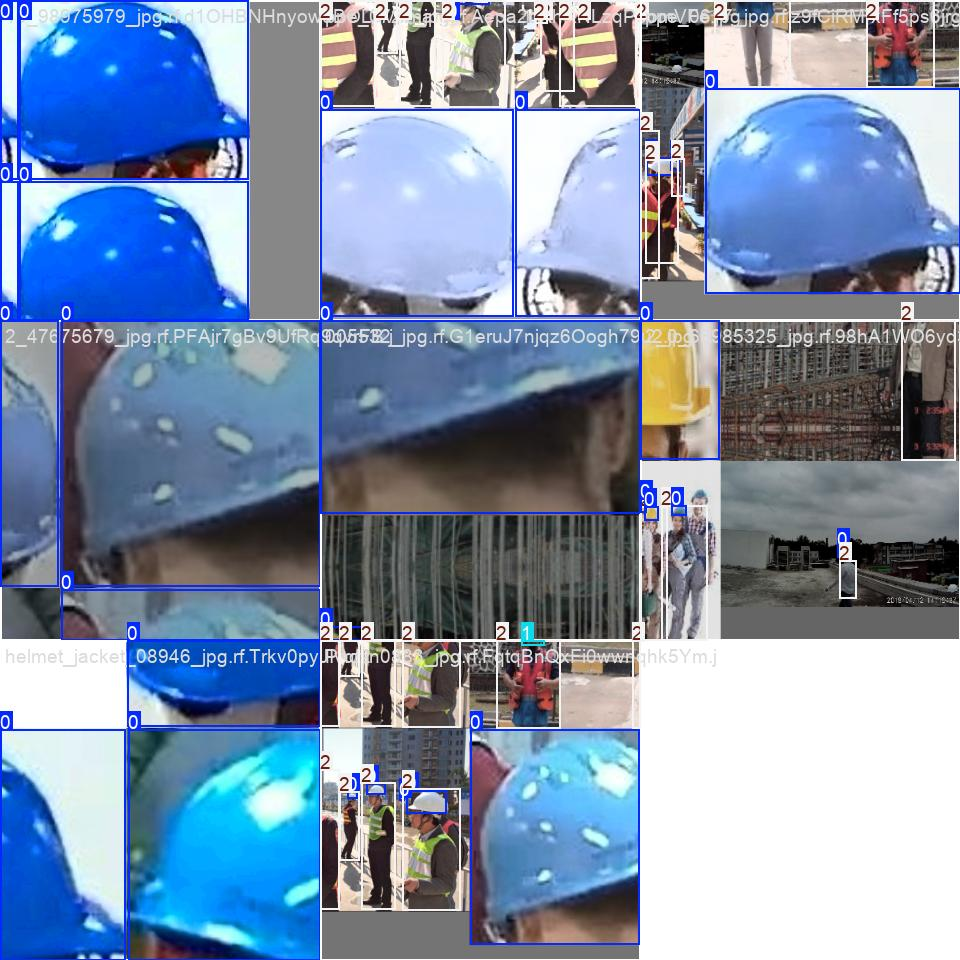

train_batch1.jpg


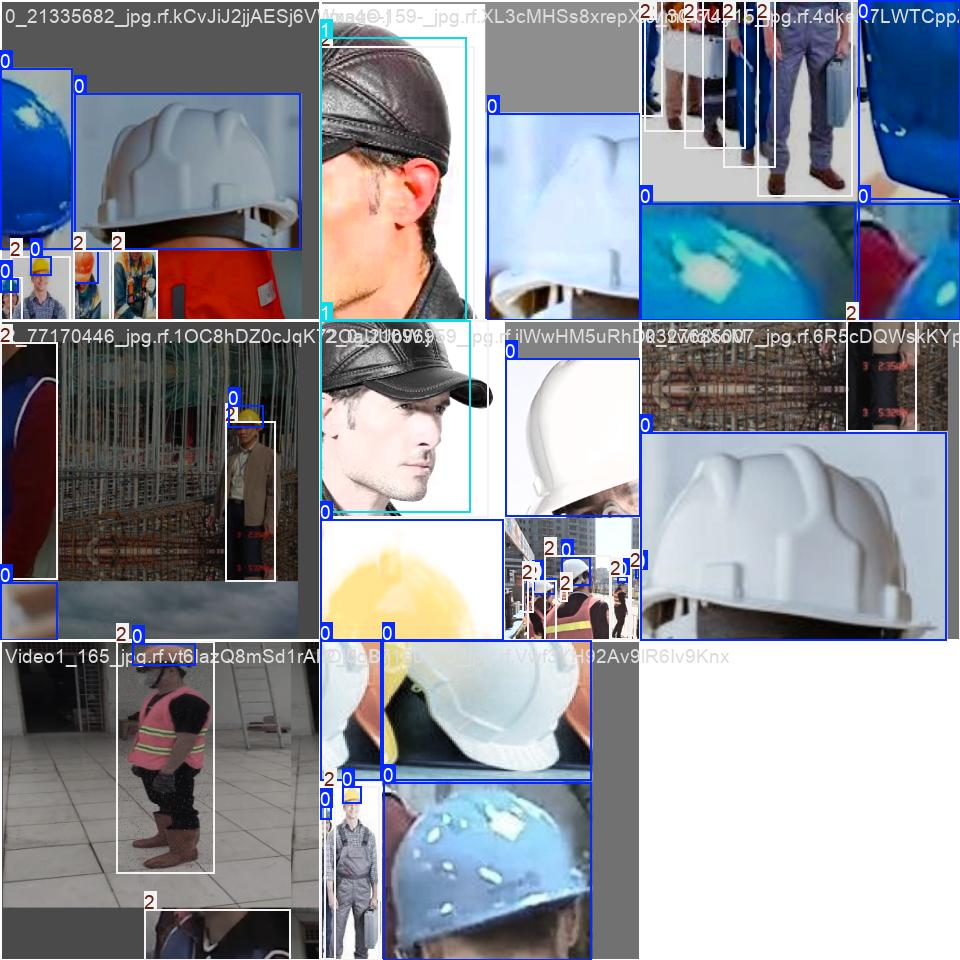

labels.jpg


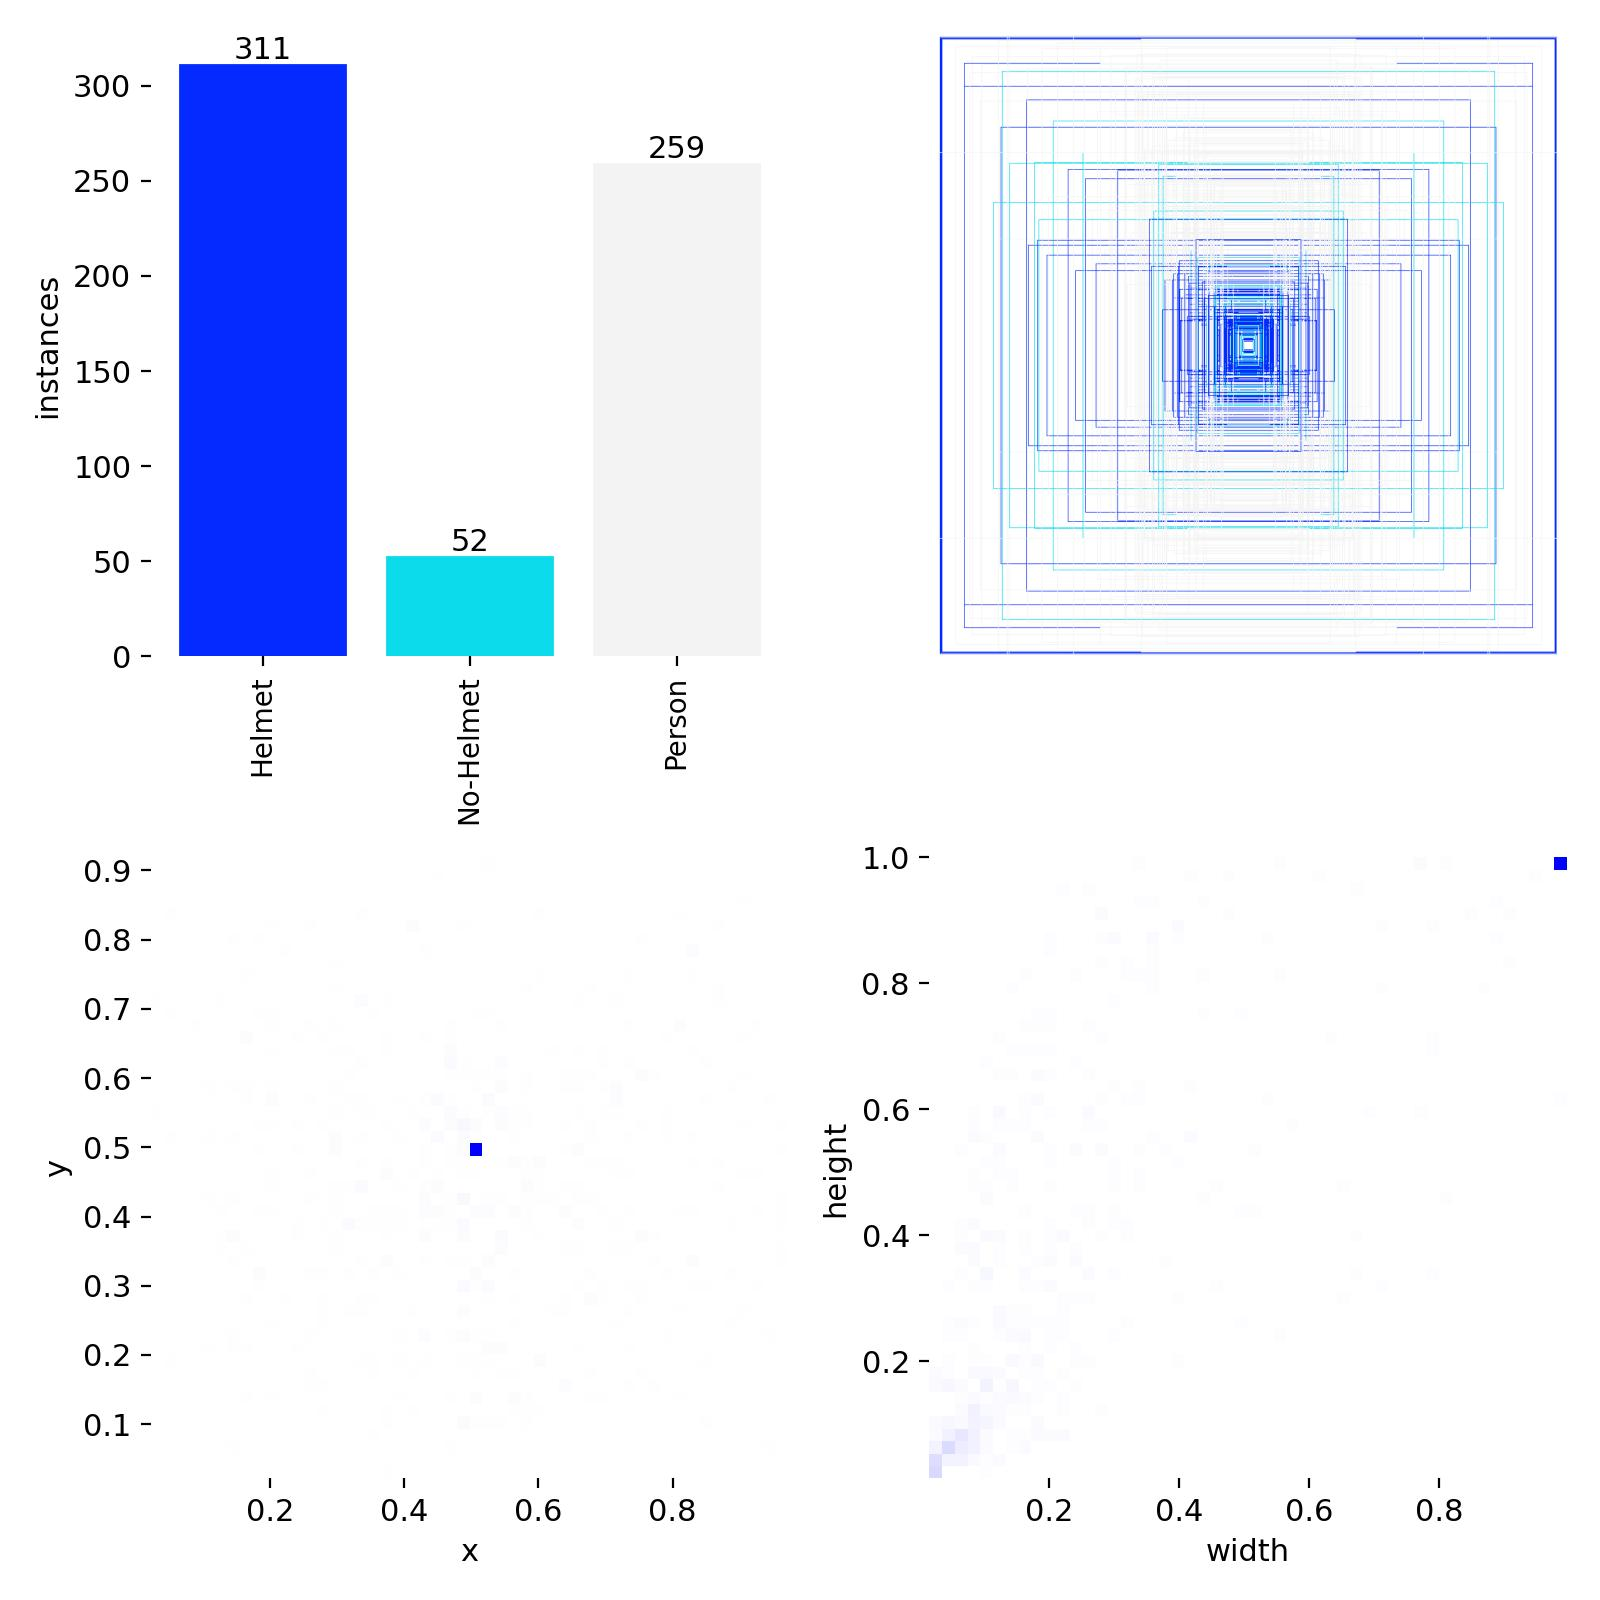

In [2]:
from pathlib import Path
from IPython.display import Image, display
run_dir = Path("runs/train/helmet_yolo26s_baseline")
if not run_dir.exists():
    print("Belum ada hasil training — jalankan sel Run dulu.")
else:
    found = False
    for png in ["train_batch0.jpg", "train_batch1.jpg", "labels.jpg", "labels_correlogram.jpg"]:
        p = run_dir / png
        if p.exists():
            found = True; print(png); display(Image(filename=str(p)))
    if not found:
        print("File preview belum ada di", run_dir)

### b. Komponen loss train vs val — *kenapa* deteksi overfitting

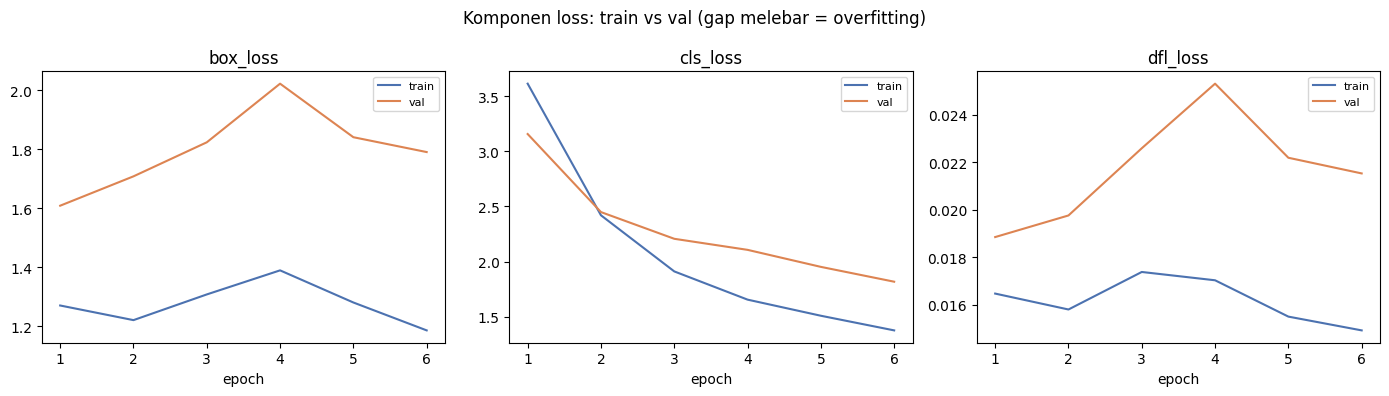

=> Bila val loss naik sementara train turun => overfitting; andalkan early-stopping (patience).


In [3]:
import pandas as pd, matplotlib.pyplot as plt
from pathlib import Path
csv = Path("runs/train/helmet_yolo26s_baseline/results.csv")
if not csv.exists():
    print("results.csv belum ada — jalankan sel Run dulu.")
else:
    df = pd.read_csv(csv); df.columns = [c.strip() for c in df.columns]
    pairs = [("train/box_loss","val/box_loss","box_loss"),
             ("train/cls_loss","val/cls_loss","cls_loss"),
             ("train/dfl_loss","val/dfl_loss","dfl_loss")]
    fig, ax = plt.subplots(1, 3, figsize=(14, 4))
    for a, (tr, vl, name) in zip(ax, pairs):
        if tr in df: a.plot(df["epoch"], df[tr], label="train", color="#4c72b0")
        if vl in df: a.plot(df["epoch"], df[vl], label="val", color="#dd8452")
        a.set_title(name); a.set_xlabel("epoch"); a.legend(fontsize=8)
    fig.suptitle("Komponen loss: train vs val (gap melebar = overfitting)")
    plt.tight_layout(); plt.show()
    print("=> Bila val loss naik sementara train turun => overfitting; andalkan early-stopping (patience).")

### c. Kurva metrik & jadwal learning rate — *kenapa* warmup/decay

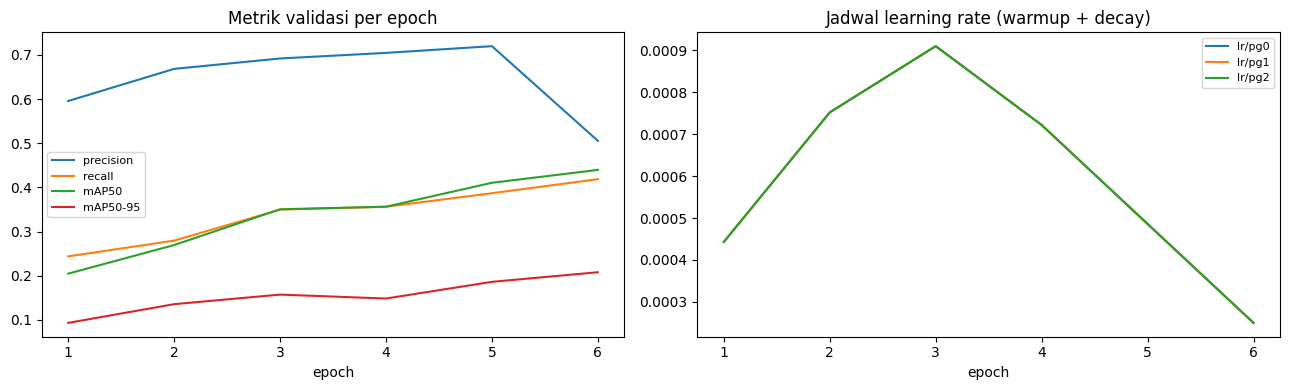

In [4]:
import pandas as pd, matplotlib.pyplot as plt
from pathlib import Path
df = pd.read_csv("runs/train/helmet_yolo26s_baseline/results.csv"); df.columns = [c.strip() for c in df.columns]
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
for c in [c for c in ["metrics/precision(B)","metrics/recall(B)","metrics/mAP50(B)","metrics/mAP50-95(B)"] if c in df]:
    ax[0].plot(df["epoch"], df[c], label=c.split("/")[-1].replace("(B)",""))
ax[0].set_title("Metrik validasi per epoch"); ax[0].set_xlabel("epoch"); ax[0].legend(fontsize=8)
for c in [c for c in df.columns if c.startswith("lr/")]:
    ax[1].plot(df["epoch"], df[c], label=c)
ax[1].set_title("Jadwal learning rate (warmup + decay)"); ax[1].set_xlabel("epoch"); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()